# Olist Brazilian E-Commerce Dataset — Exploratory Data Analysis


My Choice: Analyse orders + order_items + customers + order_payments
Why these four:

*   orders is the backbone — every other table hangs off order_id, and it holds all the lifecycle/timing data (purchase, approval, delivery, estimate). No matter what direction the team picks, this table is unavoidable.
*   order_items is the bridge — it's the only table linking orders to product_id and seller_id, plus it carries price and freight. Without it you can't connect orders to whatever your teammates do with products/sellers.
*   customers gives you the customer_unique_id vs customer_id distinction (repeat-purchase behavior), geography (state/city), and it's small and easy to work with (99K rows, 5 columns).
*   rder_payments is self-contained and rich on its own — payment type, installments, value — and it's a natural "how do people pay and does it relate to order value" mini-story that doesn't depend on the huge tables.



What I'm finding
*   Full order lifecycle and delivery-timing analysis (lead time, lateness, by state)
*   Repeat-customer behavior via customer_unique_id
*   Geography to lateness
*   Price/freight patterns per order
*   Payment method and installment behavior, and how it relates to order value






In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


pandas: 2.2.3
numpy: 2.1.3


## 1. Data Loading

In [2]:
from google.colab import drive

# === DATA PATH CONFIGURATION ===
drive.mount('/content/drive')
DATA_DIR = "/content/drive/My Drive/NUS_FinTech Masters/Y1S1/IT5006/Project/Project-Data/Olist_CSV"

if os.path.exists(DATA_DIR):
  print(f"✅ Data directory found: {DATA_DIR}")
  print(f"   Files: {os.listdir(DATA_DIR)}")
else:
    print(f"❌ Data directory not found: {DATA_DIR}")
    print("   Please update DATA_DIR to point to the correct Olist data folder")

Mounted at /content/drive
✅ Data directory found: /content/drive/My Drive/NUS_FinTech Masters/Y1S1/IT5006/Project/Project-Data/Olist_CSV
   Files: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv', 'olist_products_dataset.csv', 'olist_order_items_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv']


In [3]:
# Load all Olist tables
def load_olist_data(data_dir):
    """Load all Olist CSV files into a dictionary of DataFrames."""

    tables = {
        'orders': 'olist_orders_dataset.csv',
        'order_items': 'olist_order_items_dataset.csv',
        'customers': 'olist_customers_dataset.csv',
        'payments': 'olist_order_payments_dataset.csv',
        'products': 'olist_products_dataset.csv',
    }

    # Date columns to parse
    date_cols = {
        'orders': ['order_purchase_timestamp', 'order_approved_at','order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'],
        'order_items': ['shipping_limit_date'],
    }

    data = {}
    for name, filename in tables.items():
        filepath = os.path.join(data_dir, filename)
        parse_dates = date_cols.get(name, None)
        data[name] = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {name}: {data[name].shape[0]:,} rows × {data[name].shape[1]} cols")

    return data

olist = load_olist_data(DATA_DIR)

Loaded orders: 99,441 rows × 8 cols
Loaded order_items: 112,650 rows × 7 cols
Loaded customers: 99,441 rows × 5 cols
Loaded payments: 103,886 rows × 5 cols
Loaded products: 32,951 rows × 9 cols


In [4]:
olist['products'].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


In [9]:
df_orders = olist['orders']
df_order_items = olist['order_items']
df_customers = olist['customers']
df_payments = olist['payments']
df_products = olist['products']

You can now access each table directly as a DataFrame, for example, `df_orders.head()`.

## 2. Table-by-table profiling

Look at data types, missing data etc.

In [5]:
def profile(df, name):
    print(f'------ {name} ------')
    print(df.dtypes)
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print('\nMissing values:')
        print((nulls.to_frame('n_missing')
               .assign(pct_missing=lambda d: (d['n_missing']/len(df)*100).round(2))))
    else:
        print('\nNo missing values.')
    print()

for name, df in olist.items():
    profile(df, name)

------ orders ------
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Missing values:
                               n_missing  pct_missing
order_approved_at                    160         0.16
order_delivered_carrier_date        1783         1.79
order_delivered_customer_date       2965         2.98

------ order_items ------
order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

No missing values.

------ customers ---

## 3. Schema Overview

In [6]:
# Quick schema overview
def schema_summary(data_dict):
    """Generate a summary of all tables."""
    summary = []
    for name, df in data_dict.items():
        summary.append({
            'Table': name,
            'Rows': f"{df.shape[0]:,}",
            'Columns': df.shape[1],
            'Memory (MB)': f"{df.memory_usage(deep=True).sum() / 1e6:.2f}",
            'Columns List': ', '.join(df.columns[:5]) + ('...' if len(df.columns) > 5 else '')
        })
    return pd.DataFrame(summary)

schema_summary(olist)

,Table,Rows,Columns,Memory (MB),Columns List
0,orders,"99,441",8,25.85,"order_id, customer_id, order_status, order_pur..."
1,order_items,"112,650",7,30.98,"order_id, order_item_id, product_id, seller_id..."
2,customers,"99,441",5,27.88,"customer_id, customer_unique_id, customer_zip_..."
3,payments,"103,886",5,17.02,"order_id, payment_sequential, payment_type, pa..."
4,products,"32,951",9,6.60,"product_id, product_category_name, product_nam..."


## 4. Customers & Orders - Deep Dive

####  4.1 Customers Table

In [10]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [11]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26


In [12]:
n_customer_id = df_customers['customer_id'].nunique()
n_customer_unique_id = df_customers['customer_unique_id'].nunique()
print(f'Distinct customer_id:         {n_customer_id:,}')
print(f'Distinct customer_unique_id:  {n_customer_unique_id:,}')
print(f'Difference (extra customer_id rows from repeat buyers): {n_customer_id - n_customer_unique_id:,}')

Distinct customer_id:         99,441
Distinct customer_unique_id:  96,096
Difference (extra customer_id rows from repeat buyers): 3,345


Distribution of number of orders per real customer:
customer_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

Share of customers who ordered more than once: 3.12%


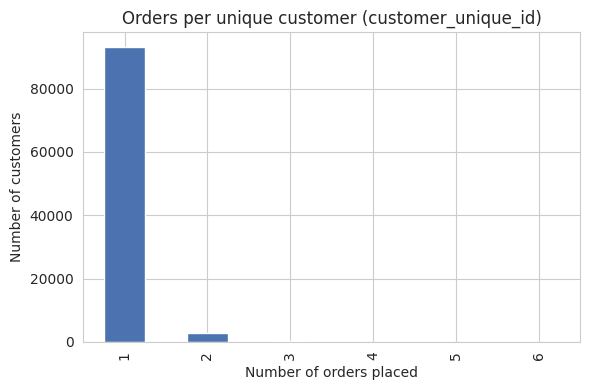

In [13]:
orders_per_customer = df_customers.groupby('customer_unique_id')['customer_id'].nunique()
dist = orders_per_customer.value_counts().sort_index()
print('Distribution of number of orders per real customer:')
print(dist.head(10))

repeat_rate = (orders_per_customer > 1).mean() * 100
print(f'\nShare of customers who ordered more than once: {repeat_rate:.2f}%')

fig, ax = plt.subplots(figsize=(6,4))
dist.head(6).plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_xlabel('Number of orders placed')
ax.set_ylabel('Number of customers')
ax.set_title('Orders per unique customer (customer_unique_id)')
plt.tight_layout()
plt.show()

#### 4.2 Orders & Orders Items Table

In [15]:
order_value = df_order_items.groupby('order_id').agg(item_total=('price','sum'), freight_total=('freight_value','sum'))
order_value['order_total'] = order_value['item_total'] + order_value['freight_total']
order_value.head()

,item_total,freight_total,order_total
order_id,,,
00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04


In [16]:
order_value.describe()

,item_total,freight_total,order_total
count,98666.00,98666.00,98666.00
mean,137.75,22.82,160.58
std,210.65,21.65,220.47
min,0.85,0.00,9.59
25%,45.90,13.85,61.98
50%,86.90,17.17,105.29
75%,149.90,24.04,176.87
max,13440.00,1794.96,13664.08


In [17]:
# Merge order value onto customers via order_items, to look at repeat buyers vs one-time buyers
df_cust_orders = df_orders[['order_id', 'customer_id']].merge(df_customers[['customer_id','customer_unique_id']], on='customer_id', how='left')
df_cust_orders = df_cust_orders.merge(order_value, on='order_id', how='left')
df_cust_orders.head()

,order_id,customer_id,customer_unique_id,item_total,freight_total,order_total
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,19.90,8.72,28.62


In [18]:
cust_summary = df_cust_orders.groupby('customer_unique_id').agg(
    n_orders=('order_id','nunique'),
    total_spend=('order_total','sum'),
    avg_order_value=('order_total','mean')
)
cust_summary['segment'] = np.where(cust_summary['n_orders'] > 1, 'repeat', 'one-time')

print(cust_summary.groupby('segment')[['total_spend','avg_order_value']].mean().round(2))
print(f"\nOne-time buyers: {(cust_summary['segment']=='one-time').sum():,} "
      f"({(cust_summary['segment']=='one-time').mean()*100:.1f}%)")
print(f"Repeat buyers:   {(cust_summary['segment']=='repeat').sum():,} "
      f"({(cust_summary['segment']=='repeat').mean()*100:.1f}%)")

          total_spend  avg_order_value
segment                               
one-time       160.28           161.43
repeat         307.66           149.01

One-time buyers: 93,099 (96.9%)
Repeat buyers:   2,997 (3.1%)


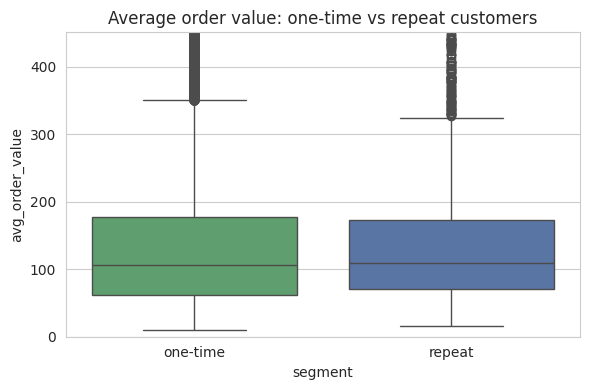

In [19]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=cust_summary, x='segment', y='avg_order_value', ax=ax, palette=['#55A868','#4C72B0'])
ax.set_ylim(0, cust_summary['avg_order_value'].quantile(0.95))
ax.set_title('Average order value: one-time vs repeat customers')
plt.tight_layout()
plt.show()


Takeaway: repeat customers are a small minority of the base. Therefore, any "predict repeat purchase" or "customer lifetime value' framing is itself a rare-event/ imbalanced problem, on top of late-delivery and low-satisfaction imbalance already flagged in the project brief

# 5. Order Status & Lifecycle Timing - Deep Dive

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

% delivered: 97.02%


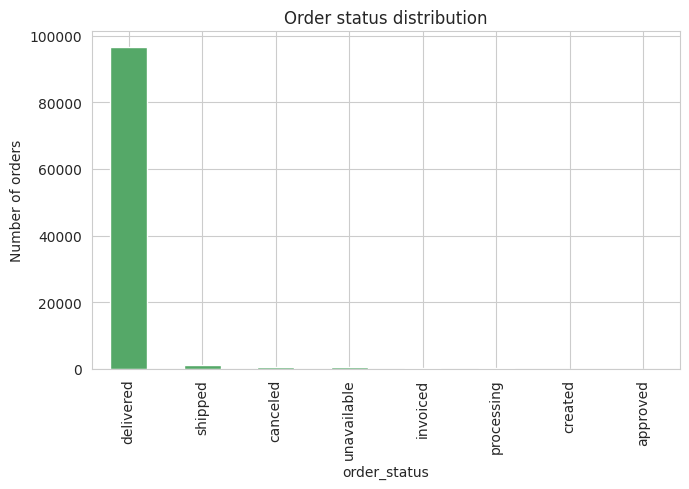

In [20]:
status_counts = df_orders['order_status'].value_counts()
print(status_counts)
print(f'\n% delivered: {status_counts.get("delivered", 0) / len(df_orders) * 100:.2f}%')

fig, ax = plt.subplots(figsize=(7,5))
status_counts.plot(kind='bar', ax=ax, color='#55A868')
ax.set_title('Order status distribution')
ax.set_ylabel('Number of orders')
plt.tight_layout()
plt.show()

In [21]:
df_orders_delivered = df_orders[df_orders['order_status'] == 'delivered'].copy()

df_orders_delivered['days_to_approval'] = (df_orders_delivered['order_approved_at'] - df_orders_delivered['order_purchase_timestamp']).dt.total_seconds() / 86400
df_orders_delivered['days_to_carrier'] = (df_orders_delivered['order_delivered_carrier_date'] - df_orders_delivered['order_approved_at']).dt.total_seconds() / 86400
df_orders_delivered['days_carrier_to_customer'] = (df_orders_delivered['order_delivered_customer_date'] - df_orders_delivered['order_delivered_carrier_date']).dt.total_seconds() / 86400
df_orders_delivered['days_to_customer'] = (df_orders_delivered['order_delivered_customer_date'] - df_orders_delivered['order_purchase_timestamp']).dt.total_seconds() / 86400
df_orders_delivered['delivery_delay_days'] = (df_orders_delivered['order_delivered_customer_date'] - df_orders_delivered['order_estimated_delivery_date']).dt.total_seconds() / 86400
df_orders_delivered['is_late'] = df_orders_delivered['delivery_delay_days'] > 0

print("Total no. of orders delivered", len(df_orders_delivered))
print("Total no. of orders that arrived late", len(df_orders_delivered[df_orders_delivered['is_late']]))
print(f'Percentage of delivered orders that arrived late: {df_orders_delivered["is_late"].mean()*100:.2f}%')

Total no. of orders delivered 96478
Total no. of orders that arrived late 7826
Percentage of delivered orders that arrived late: 8.11%


In [22]:
df_orders_delivered.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,days_to_approval,days_to_carrier,days_carrier_to_customer,days_to_customer,delivery_delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,0.01,2.37,6.06,8.44,-7.11,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,1.28,0.46,12.04,13.78,-5.36,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,0.01,0.20,9.18,9.39,-17.25,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,0.01,3.75,9.45,13.21,-12.98,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,0.04,0.89,1.94,2.87,-9.24,False


Average days spent in each stage:
days_to_approval           0.43
days_to_carrier            2.80
days_carrier_to_customer   9.33
dtype: float64


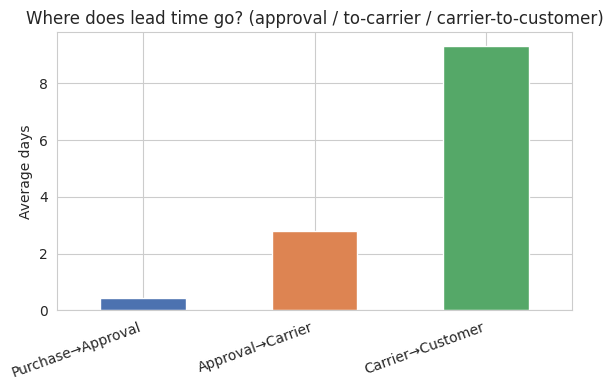

In [23]:
# Break the total lead time into its three stages to see where time is actually spent
stage_means = df_orders_delivered[['days_to_approval','days_to_carrier','days_carrier_to_customer']].mean()
print('Average days spent in each stage:')
print(stage_means.round(2))

fig, ax = plt.subplots(figsize=(6,4))
stage_means.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452','#55A868'])
ax.set_ylabel('Average days')
ax.set_title('Where does lead time go? (approval / to-carrier / carrier-to-customer)')
ax.set_xticklabels(['Purchase→Approval','Approval→Carrier','Carrier→Customer'], rotation=20, ha='right')
plt.tight_layout()
plt.show()

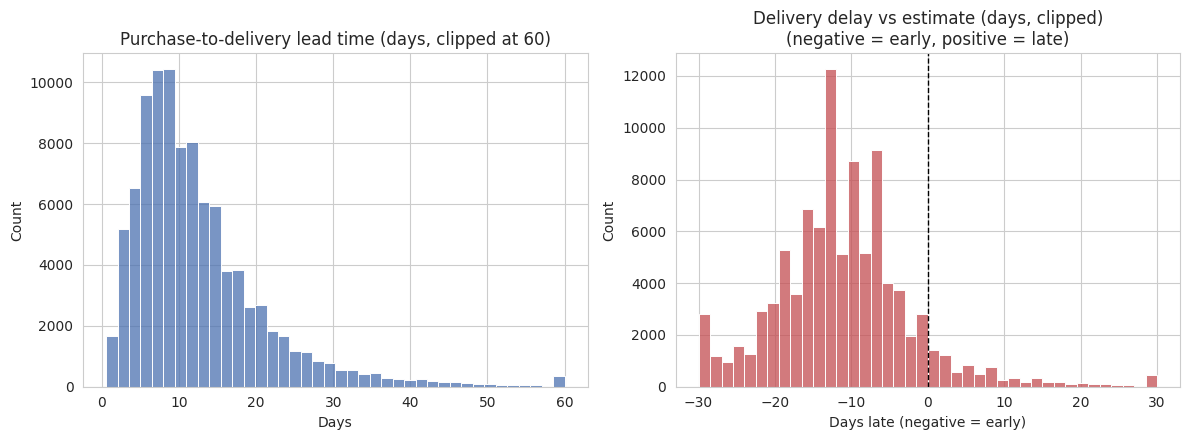

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

sns.histplot(df_orders_delivered['days_to_customer'].clip(0, 60), bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('Purchase-to-delivery lead time (days, clipped at 60)')
axes[0].set_xlabel('Days')

sns.histplot(df_orders_delivered['delivery_delay_days'].clip(-30, 30), bins=40, ax=axes[1], color='#C44E52')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Delivery delay vs estimate (days, clipped)\n(negative = early, positive = late)')
axes[1].set_xlabel('Days late (negative = early)')

plt.tight_layout()
plt.show()


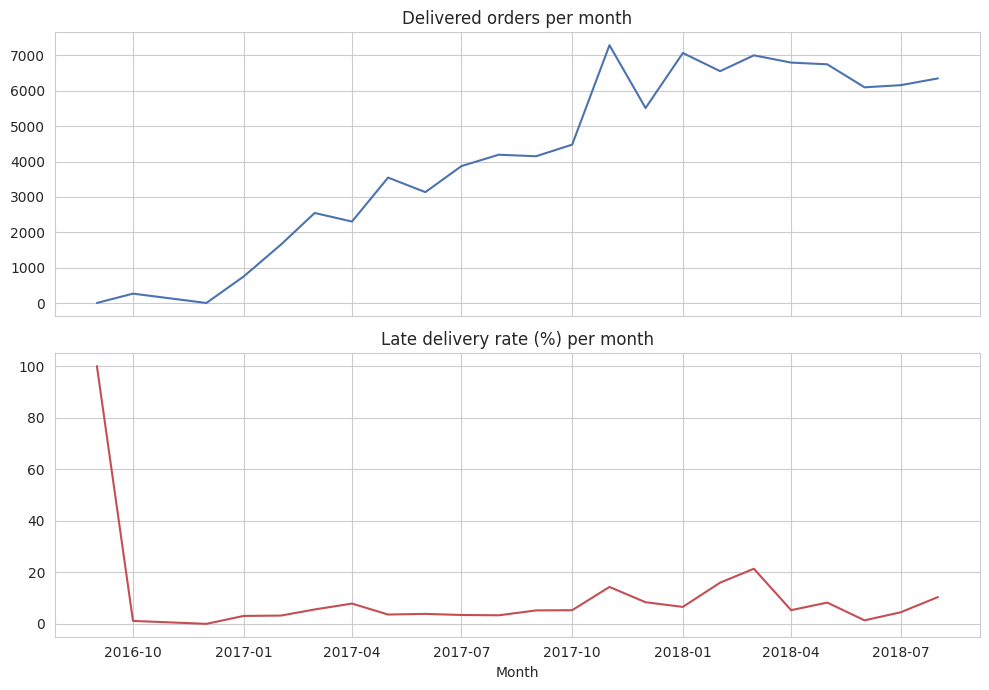

In [25]:
# Timing trend over the 2016-2018 period
df_orders_delivered['purchase_month'] = df_orders_delivered['order_purchase_timestamp'].dt.to_period('M')
monthly = df_orders_delivered.groupby('purchase_month').agg(n_orders=('order_id','count'),
                                                            avg_lead_time=('days_to_customer','mean'),
                                                            late_rate=('is_late','mean'))
monthly.index = monthly.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(10,7), sharex=True)
axes[0].plot(monthly.index, monthly['n_orders'], color='#4C72B0')
axes[0].set_title('Delivered orders per month')
axes[1].plot(monthly.index, monthly['late_rate']*100, color='#C44E52')
axes[1].set_title('Late delivery rate (%) per month')
axes[1].set_xlabel('Month')
plt.tight_layout()
plt.show()


**Takeaway:** most of the lead time sits in the carrier-to-customer leg, not order approval —
worth looking into *why* orders are late, not just predict *whether*.
There's also a visible spike in order volume (Black Friday, Nov 2017) — worth checking whether
late-delivery rate spikes alongside it, which would support adding a seasonality/volume feature.

# 6. Order items - price & freight - Deep Dive

`order_items` is the bridge to `product_id`/`seller_id` and carries price/freight per line item.

          price  freight_value
count 112650.00      112650.00
mean     120.65          19.99
std      183.63          15.81
min        0.85           0.00
25%       39.90          13.08
50%       74.99          16.26
75%      134.90          21.15
max     6735.00         409.68


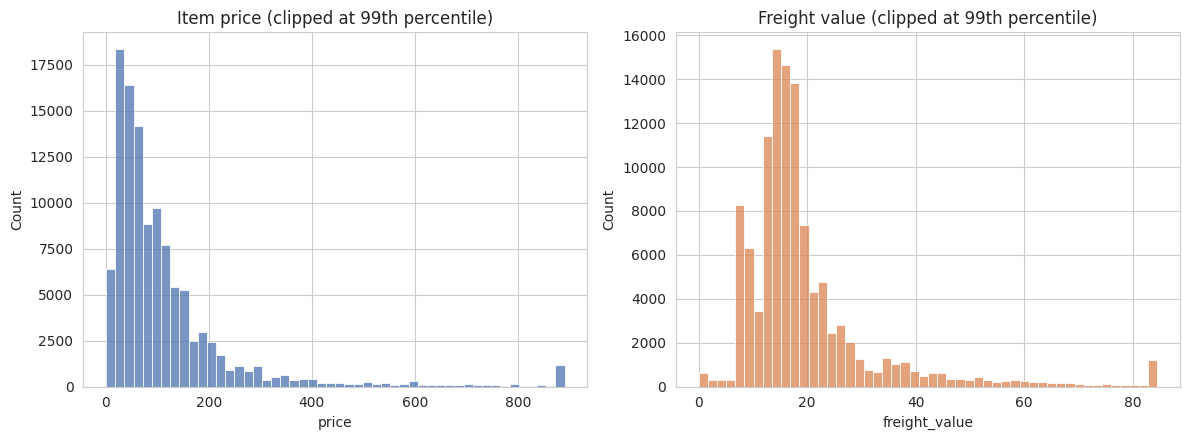

In [26]:
print(df_order_items[['price','freight_value']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.histplot(df_order_items['price'].clip(upper=df_order_items['price'].quantile(0.99)), bins=50, ax=axes[0], color='#4C72B0')
axes[0].set_title('Item price (clipped at 99th percentile)')
sns.histplot(df_order_items['freight_value'].clip(upper=df_order_items['freight_value'].quantile(0.99)), bins=50, ax=axes[1], color='#DD8452')
axes[1].set_title('Freight value (clipped at 99th percentile)')
plt.tight_layout()
plt.show()


In [27]:
df_order_items ['freight_ratio'] = df_order_items['freight_value'] / df_order_items['price'].replace(0, np.nan)
df_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,freight_ratio
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,0.23
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,0.08
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,0.09
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,0.98
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,0.09


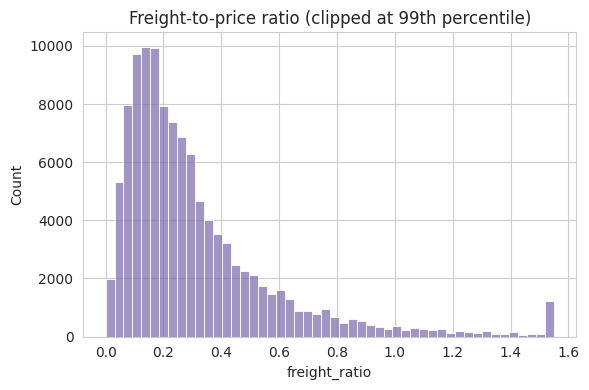

In [28]:
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(df_order_items['freight_ratio'].clip(upper=df_order_items['freight_ratio'].quantile(0.99)), bins=50, color='#8172B2', ax=ax)
ax.set_title('Freight-to-price ratio (clipped at 99th percentile)')
plt.tight_layout()
plt.show()

In [29]:
# Items per order distribution
items_per_order = df_order_items.groupby('order_id')['order_item_id'].count()
print(items_per_order.value_counts().sort_index().head())
print(f'\n% of orders with a single item: {(items_per_order==1).mean()*100:.1f}%')

order_item_id
1    88863
2     7516
3     1322
4      505
5      204
Name: count, dtype: int64

% of orders with a single item: 90.1%


**Takeaway:** most orders contain a single item, and freight is a substantial share of price
for lower-value items — freight ratio could be a useful feature on its own (a proxy for both
distance and item bulkiness) rather than raw freight value.

# 7. Payments - Deep Dive

In [30]:
print('Payment type distribution:')
print(df_payments['payment_type'].value_counts())

Payment type distribution:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


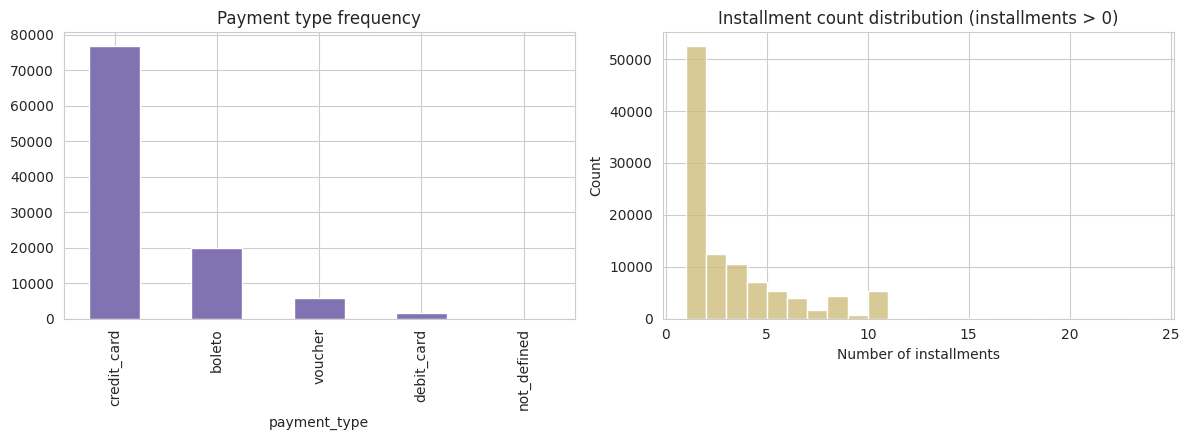

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
df_payments['payment_type'].value_counts().plot(kind='bar', ax=axes[0], color='#8172B2')
axes[0].set_title('Payment type frequency')

sns.histplot(df_payments.loc[df_payments['payment_installments']>0, 'payment_installments'],
             bins=range(1,25), ax=axes[1], color='#CCB974')
axes[1].set_title('Installment count distribution (installments > 0)')
axes[1].set_xlabel('Number of installments')
plt.tight_layout()
plt.show()

Share of orders with a split payment (2+ payment rows): 2.98%


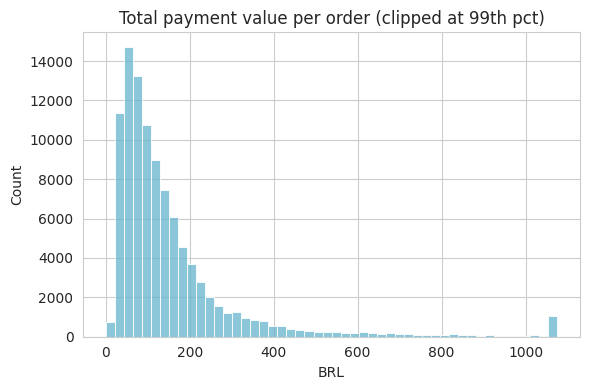

In [32]:
# Orders with more than one payment row (split payments)
payment_rows_per_order = df_payments.groupby('order_id').size()
split_rate = (payment_rows_per_order > 1).mean() * 100
print(f'Share of orders with a split payment (2+ payment rows): {split_rate:.2f}%')

order_payment_totals = df_payments.groupby('order_id')['payment_value'].sum()

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(order_payment_totals.clip(upper=order_payment_totals.quantile(0.99)), bins=50, color='#64B5CD', ax=ax)
ax.set_title('Total payment value per order (clipped at 99th pct)')
ax.set_xlabel('BRL')
plt.tight_layout()
plt.show()

In [33]:
credit_card_payments = df_payments[df_payments['payment_type'] == 'credit_card']
installments_zero_or_less = credit_card_payments[credit_card_payments['payment_installments'] <= 0]

if not installments_zero_or_less.empty:
    print(f"There are {len(installments_zero_or_less)} 'credit_card' payments with 0 or less installments.")
    print("Here are some examples:")
    display(installments_zero_or_less.head())
else:
    print("All 'credit_card' payments are associated with payment installments (i.e., payment_installments > 0).")

There are 2 'credit_card' payments with 0 or less installments.
Here are some examples:


,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [34]:
payment_type_with_installments = df_payments[df_payments['payment_installments'] > 0]
installment_orders_count = payment_type_with_installments.groupby('payment_type')['order_id'].nunique().rename('Orders with Installments')

# Total unique orders per payment type
total_orders_per_type = df_payments.groupby('payment_type')['order_id'].nunique().rename('Total Unique Orders')

# Calculate percentage of orders with installments
combined_df = pd.concat([total_orders_per_type, installment_orders_count], axis=1).fillna(0)
combined_df['Percentage with Installments (%)'] = (combined_df['Orders with Installments'] / combined_df['Total Unique Orders'] * 100).round(2)

print("Payment Type Installment Summary:")
display(combined_df.sort_values(by='Percentage with Installments (%)', ascending=False))

Payment Type Installment Summary:


,Total Unique Orders,Orders with Installments,Percentage with Installments (%)
payment_type,,,
boleto,19784,19784,100.00
credit_card,76505,76503,100.00
debit_card,1528,1528,100.00
not_defined,3,3,100.00
voucher,3866,3866,100.00


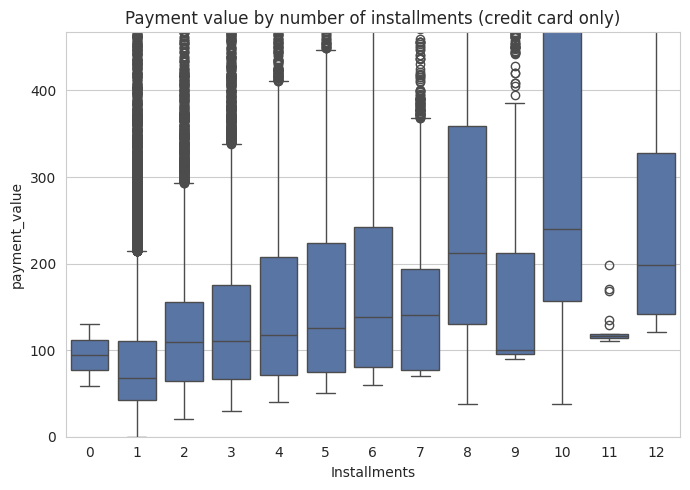

In [35]:
# Installments vs order value, and installments by payment type — is buying on credit
# associated with higher-value purchases?
cc_payments = df_payments[df_payments['payment_type']=='credit_card']

fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=cc_payments, x='payment_installments', y='payment_value',
            order=sorted(cc_payments['payment_installments'].unique())[:13], ax=ax, color='#4C72B0')
ax.set_ylim(0, cc_payments['payment_value'].quantile(0.95))
ax.set_title('Payment value by number of installments (credit card only)')
ax.set_xlabel('Installments')
plt.tight_layout()
plt.show()


**Takeaway:** credit card dominates as a payment method, split payments are rare, and higher
installment counts are associated with higher payment values — consistent with installments being
used to finance bigger-ticket purchases rather than being evenly spread across all order sizes.

# 8. Merge datasets - orders, items, customers, and payments together

In [ ]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [37]:
# Build one order-level table combining item totals, payment totals, delivery timing,
# customer identity, and geography — this is the actual join across all four tables.
order_full = df_orders.merge(
    df_customers[['customer_id', 'customer_unique_id', 'customer_state']],
    on='customer_id', how='left'
)
order_full = order_full.merge(order_value[['order_total']], on='order_id', how='left')
order_full = order_full.merge(order_payment_totals.rename('payment_total'), on='order_id', how='left')

order_full.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,order_total,payment_total
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,38.71,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,af07308b275d755c9edb36a90c618231,BA,141.46,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,179.12,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,7c142cf63193a1473d2e66489a9ae977,RN,72.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,SP,28.62,28.62


In [39]:
# Restrict to delivered orders and bring in the timing fields computed earlier
delivered_full = order_full[order_full['order_status'] == 'delivered'].merge(
    df_orders_delivered[['order_id', 'days_to_customer', 'delivery_delay_days', 'is_late']],
    on='order_id', how='inner'
)

delivered_full.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,order_total,payment_total,days_to_customer,delivery_delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,38.71,38.71,8.44,-7.11,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,af07308b275d755c9edb36a90c618231,BA,141.46,141.46,13.78,-5.36,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,179.12,179.12,9.39,-17.25,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,7c142cf63193a1473d2e66489a9ae977,RN,72.20,72.20,13.21,-12.98,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,SP,28.62,28.62,2.87,-9.24,False


### 8.1 Does order value relate to delivery performance?

Correlation between order_total and lead time / delay:
                     order_total  days_to_customer  delivery_delay_days
order_total                 1.00              0.07                -0.02
days_to_customer            0.07              1.00                 0.61
delivery_delay_days        -0.02              0.61                 1.00


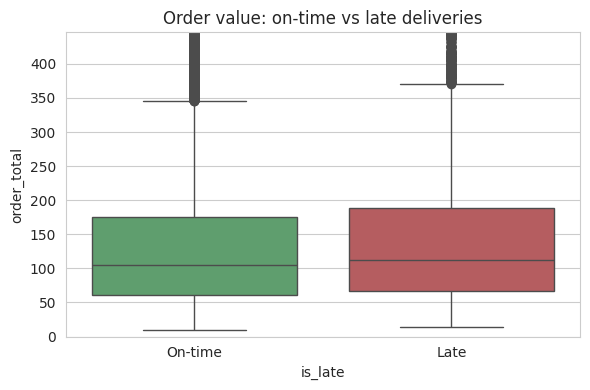

In [40]:
print('Correlation between order_total and lead time / delay:')
print(delivered_full[['order_total', 'days_to_customer', 'delivery_delay_days']].corr().round(3))

fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=delivered_full, x='is_late', y='order_total', ax=ax, palette=['#55A868','#C44E52'])
ax.set_ylim(0, delivered_full['order_total'].quantile(0.95))
ax.set_xticklabels(['On-time', 'Late'])
ax.set_title('Order value: on-time vs late deliveries')
plt.tight_layout()
plt.show()

Note:
- Close to +1 → strong positive relationship (bigger orders take longer to arrive)
- Close to -1 → strong negative relationship (bigger orders arrive faster)
- Close to 0 → no relationship — order value tells you nothing about delivery timing

Findings: spending more doesn't make your order arrive faster or slower, and it doesn't make it more or less likely to be late.

### 8.2 Does geography (customer state) explain delivery performance?

State-level view combining order volume, average spend, and delivery timing in one table —
this is only possible once `customers` and the timing fields are joined together.

In [41]:
state_summary = delivered_full.groupby('customer_state').agg(
    n_orders=('order_id', 'count'),
    avg_order_value=('order_total', 'mean'),
    avg_lead_time=('days_to_customer', 'mean'),
    late_rate=('is_late', 'mean')
).sort_values('n_orders', ascending=False)

state_summary['late_rate'] = (state_summary['late_rate'] * 100).round(1)
state_summary[['avg_order_value', 'avg_lead_time']] = state_summary[['avg_order_value', 'avg_lead_time']].round(1)
state_summary.head(15)


,n_orders,avg_order_value,avg_lead_time,late_rate
customer_state,,,,
SP,40501,142.50,8.80,5.90
RJ,12350,166.40,15.30,13.50
MG,11354,160.20,12.00,5.60
RS,5345,161.20,15.30,7.10
PR,4923,158.80,12.00,5.00
SC,3546,167.80,15.00,9.80
BA,3256,181.60,19.30,14.00
DF,2080,166.40,13.00,7.10
ES,1995,159.20,15.80,12.20


Interpretation: this is not a small effect. SP customers get their orders in under 9 days on average with under 6% arriving late. Customers in MA wait more than twice as long (21.6 days) and have a 3–4x higher chance of a late delivery. This tracks with BA geography — SP is where most sellers/warehouses are concentrated, so nearby states get fast, reliable shipping, and distant northern/northeastern states get slower, less predictable shipping.

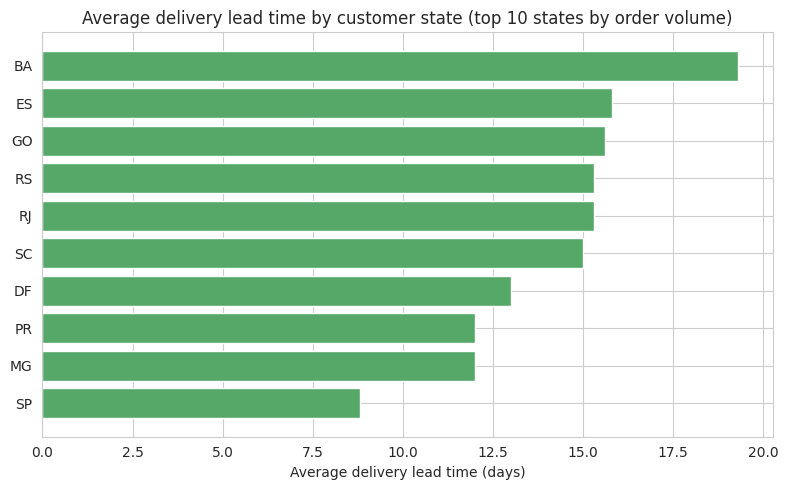

In [42]:
top_states = state_summary.head(10).sort_values('avg_lead_time')

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(top_states.index, top_states['avg_lead_time'], color='#55A868')
ax.set_xlabel('Average delivery lead time (days)')
ax.set_title('Average delivery lead time by customer state (top 10 states by order volume)')
plt.tight_layout()
plt.show()


### 8.3 Do repeat customers get better delivery outcomes?

This uses the `segment` (repeat vs one-time) built earlier from `customer_unique_id`, joined onto
the delivery timing data — a question that's only answerable once customers and orders are linked
correctly.

In [43]:
delivered_full_seg = delivered_full.merge(
    cust_summary[['segment']], left_on='customer_unique_id', right_index=True, how='left'
)

seg_delivery = delivered_full_seg.groupby('segment').agg(
    n_orders=('order_id', 'count'),
    late_rate=('is_late', 'mean'),
    avg_lead_time=('days_to_customer', 'mean')
)
seg_delivery['late_rate'] = (seg_delivery['late_rate'] * 100).round(2)
seg_delivery['avg_lead_time'] = seg_delivery['avg_lead_time'].round(2)
print(seg_delivery)


          n_orders  late_rate  avg_lead_time
segment                                     
one-time     90379       8.18          12.57
repeat        6099       7.03          12.31


Findings: Not much effect. May not be a useful variable

### 8.4 Does freight ratio or installment count relate to lateness?

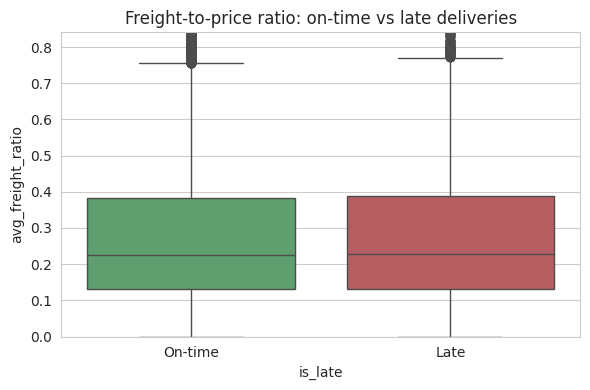

In [44]:
# Freight ratio per order (average across items in that order) joined onto delivery outcome
freight_ratio_per_order = df_order_items.groupby('order_id')['freight_ratio'].mean().rename('avg_freight_ratio')
delivered_full_fr = delivered_full.merge(freight_ratio_per_order, on='order_id', how='left')

fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=delivered_full_fr, x='is_late', y='avg_freight_ratio', ax=ax, palette=['#55A868','#C44E52'])
ax.set_ylim(0, delivered_full_fr['avg_freight_ratio'].quantile(0.95))
ax.set_xticklabels(['On-time', 'Late'])
ax.set_title('Freight-to-price ratio: on-time vs late deliveries')
plt.tight_layout()
plt.show()


In [45]:
# Max installment count per order, joined onto delivery outcome
installments_per_order = df_payments.groupby('order_id')['payment_installments'].max().rename('max_installments')
delivered_full_inst = delivered_full.merge(installments_per_order, on='order_id', how='left')

installment_bucket = pd.cut(delivered_full_inst['max_installments'],
                             bins=[-1, 0, 3, 6, 100], labels=['0', '1-3', '4-6', '7+'])
late_by_installment = delivered_full_inst.groupby(installment_bucket, observed=True)['is_late'].mean() * 100
print('Late-delivery rate (%) by installment bucket:')
print(late_by_installment.round(2))


Late-delivery rate (%) by installment bucket:
max_installments
0     0.00
1-3   7.98
4-6   8.23
7+    8.71
Name: is_late, dtype: float64


Intepretation: **Freight ratio and installment count are worth testing as model features**, though neither
  shows a drastic relationship — they may matter more in combination with state or
  category.

# 9. Deeper Analysis — Correlation, Temporal Patterns, and a Baseline Feasibility Model

The sections above establish *what* relates to delivery performance one variable at a time. This
section goes further: it looks at everything together (correlation heatmap), checks for time-based
structure (day-of-week / hour patterns), and — most importantly — builds a **baseline model** to
directly test whether the ML direction the team is proposing (predict lead time, derive a late
flag) is actually learnable from these four tables, compared against a naive baseline.

### 9.1 Correlation heatmap — everything together, not just pairwise

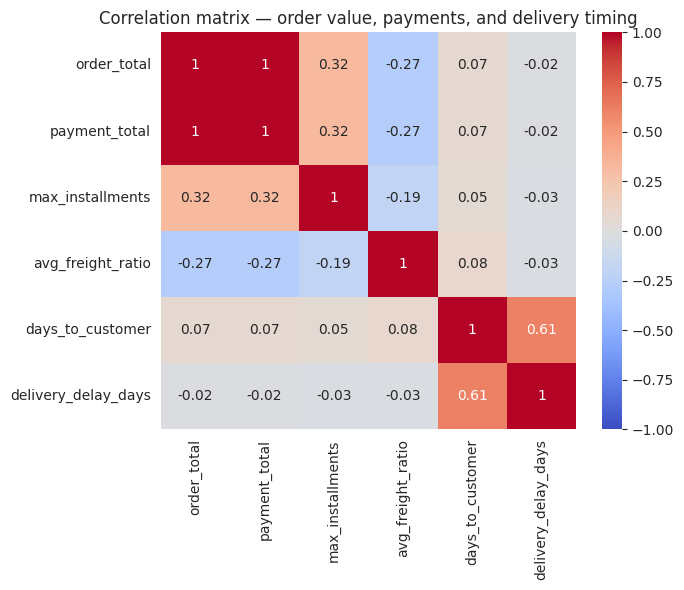

In [46]:
# Bring all the numeric features built so far into one frame for a full correlation view
corr_df = delivered_full.merge(installments_per_order, on='order_id', how='left')
corr_df = corr_df.merge(freight_ratio_per_order, on='order_id', how='left')

corr_cols = ['order_total', 'payment_total', 'max_installments', 'avg_freight_ratio',
             'days_to_customer', 'delivery_delay_days']
corr_matrix = corr_df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation matrix — order value, payments, and delivery timing')
plt.tight_layout()
plt.show()


### 9.2 Temporal patterns — does when an order is placed matter?

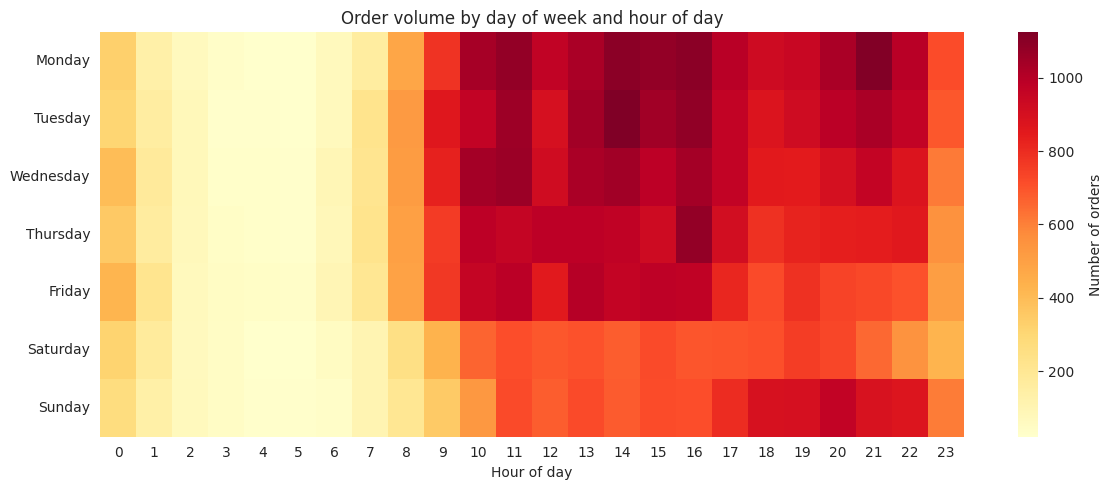

In [47]:
order_time = df_orders[['order_id', 'order_purchase_timestamp']].copy()
order_time['day_of_week'] = order_time['order_purchase_timestamp'].dt.day_name()
order_time['hour'] = order_time['order_purchase_timestamp'].dt.hour

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat_data = (order_time.groupby(['day_of_week','hour']).size()
             .reset_index(name='n_orders')
             .pivot(index='day_of_week', columns='hour', values='n_orders')
             .reindex(dow_order))

fig, ax = plt.subplots(figsize=(12,5))
sns.heatmap(heat_data, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Number of orders'})
ax.set_title('Order volume by day of week and hour of day')
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


Late-delivery rate (%) by day of week:
day_of_week
Monday      9.05
Tuesday     8.49
Wednesday   7.80
Thursday    7.57
Friday      8.45
Saturday    7.60
Sunday      7.49
Name: is_late, dtype: float64


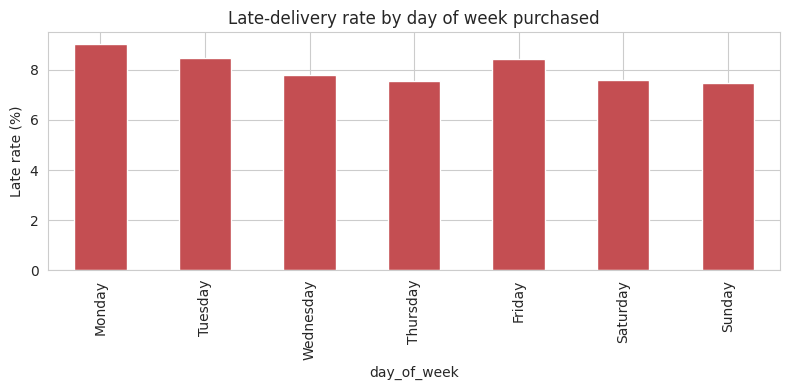

In [48]:
# Does purchase timing (day of week / hour) relate to late-delivery rate?
delivered_time = delivered_full.merge(order_time[['order_id','day_of_week','hour']], on='order_id', how='left')

late_by_dow = delivered_time.groupby('day_of_week')['is_late'].mean().reindex(dow_order) * 100
print('Late-delivery rate (%) by day of week:')
print(late_by_dow.round(2))

fig, ax = plt.subplots(figsize=(8,4))
late_by_dow.plot(kind='bar', ax=ax, color='#C44E52')
ax.set_ylabel('Late rate (%)')
ax.set_title('Late-delivery rate by day of week purchased')
plt.tight_layout()
plt.show()


**Reading it:** order volume is heavily concentrated in business hours on weekdays, with a
visible afternoon peak — useful operationally, but late-delivery rate barely moves across days of
the week. Purchase timing looks like a weak feature for the delivery-risk model; it's more useful
context (staffing/capacity planning) than a predictive signal.